# AI-Powered E-Commerce Customer Churn Analytics & Retention Decision Support System

**IBM SkillsBuild Data Analytics & AI Internship 2026**  
**Author:** Sumit Raj

This is the consolidated code submission notebook. It reproduces the implemented analytical workflow using the same project modules and paths in the GitHub repository: audit → cleaning → snapshot features/RFM → `Churn_90D` → Logistic Regression → evaluation → operational risk scoring.

All calculations are performed **in memory**. No files are written to `data/processed/`, `models/`, `reports/`, `assets/`, or `presentation/`.

**Snapshot:** 31-Aug-2011  
**Future label window:** 01-Sep-2011 to 29-Nov-2011

The full Streamlit dashboard source remains in `app/` in the GitHub repository.

## 0. Imports and project constants

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    average_precision_score,
)
from sklearn.model_selection import train_test_split

from src.config import (
    RAW_DATA_PATH,
    EXPECTED_COLUMNS,
    SNAPSHOT_DATE,
    OBSERVATION_END,
    FUTURE_START,
    FUTURE_END,
)
from src.data.load import load_raw
from src.data.clean import (
    audit_raw,
    remove_exact_duplicates,
    flag_cancellations,
    filter_qualifying_purchases,
    get_eligible_customer_ids,
)
from src.features.rfm import compute_customer_features, add_rfm_scores
from src.features.churn_label import generate_churn_label
from src.insights import build_customer_risk_table
from src.models.train import build_pipeline, NUMERIC_FEATURES
from src.models.evaluate import (
    compute_metrics,
    threshold_analysis,
    get_feature_importance,
)

warnings.filterwarnings("ignore")
print("Repository:", Path.cwd())
print("Dataset:", RAW_DATA_PATH)
print(f"Snapshot date : {SNAPSHOT_DATE.date()}")
print(f"Future window : {FUTURE_START.date()} → {FUTURE_END.date()}")

Repository: D:\IBM_SkillsBuild_Data_Analytics_AI_Internship_2026\ecommerce-churn-analytics
Dataset: D:\IBM_SkillsBuild_Data_Analytics_AI_Internship_2026\ecommerce-churn-analytics\data\raw\Online Retail.xlsx
Snapshot date : 2011-08-31
Future window : 2011-09-01 → 2011-11-29


## 1. Data audit

In [2]:
# Load raw workbook — never modify data/raw/
df_raw = load_raw()

print(f"Raw rows    : {len(df_raw):,}")
print(f"Columns     : {len(df_raw.columns)}")
print(f"Date range  : {df_raw['InvoiceDate'].min()} → {df_raw['InvoiceDate'].max()}")

audit = audit_raw(df_raw)
print(f"\nMissing Description (before fill) : {audit['missing_description']:,}")
print(f"Exact duplicates (before dedup)   : {audit['exact_duplicates']:,}")
print()
display(pd.DataFrame(audit, index=["value"]).T)

Raw rows    : 541,909
Columns     : 8
Date range  : 2010-12-01 08:26:00 → 2011-12-09 12:50:00



Missing Description (before fill) : 1,454
Exact duplicates (before dedup)   : 5,268



,value
raw_rows,541909
raw_columns,8
missing_customer_id,135080
missing_description,1454
exact_duplicates,5268
cancellation_rows,9288
negative_quantity_rows,10624
zero_quantity_rows,0
non_positive_quantity_rows,10624
negative_unit_price_rows,2


## 2. Data cleaning

In [3]:
# Step 1: copy raw and fill missing Description BEFORE deduplication
df_norm = df_raw.copy()
missing_desc_before_fill = df_norm["Description"].isna().sum()
df_norm["Description"] = df_norm["Description"].fillna("Unknown")
print(f"Missing Description before fill : {missing_desc_before_fill:,}")

# Step 2: remove exact duplicates AFTER Description normalisation
df_dedup = remove_exact_duplicates(df_norm)
print(f"Rows after exact deduplication  : {len(df_dedup):,}")

# Step 3: flag cancellations (adds IsCancellation column — retained in qualified df)
df_flagged = flag_cancellations(df_dedup)

# Step 4: apply qualifying-purchase filter (in memory — no file write)
df_qualified = filter_qualifying_purchases(df_flagged)
print(f"Qualified transaction rows      : {len(df_qualified):,}")
print(f"Qualified customers             : {df_qualified['CustomerID'].nunique():,}")

# Verify IsCancellation column is retained
assert "IsCancellation" in df_qualified.columns, "IsCancellation column missing from qualified df"
print("\ndf_qualified columns:", list(df_qualified.columns))

Missing Description before fill : 1,454


Rows after exact deduplication  : 536,641
Qualified transaction rows      : 392,692
Qualified customers             : 4,338

df_qualified columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'IsCancellation', 'Revenue']


## 3. Snapshot, eligibility, customer features and RFM scoring

In [4]:
# Date-level comparison ensures all intraday transactions on 2011-08-31 are included
_dates = df_qualified["InvoiceDate"].dt.date
df_obs = df_qualified[_dates <= OBSERVATION_END.date()].copy()
df_future = df_qualified[
    (_dates >= FUTURE_START.date()) & (_dates <= FUTURE_END.date())
].copy()

print(f"Observation transactions : {len(df_obs):,}")
print(f"Future transactions      : {len(df_future):,}")

# Eligibility: ≥ 2 distinct qualifying invoices AND ≥ 30 days span
eligible_ids = get_eligible_customer_ids(df_obs, snapshot=SNAPSHOT_DATE)
print(f"Eligible customers       : {len(eligible_ids):,}")

# Build customer feature table from observation period only (no leakage)
df_eligible_obs = df_obs[df_obs["CustomerID"].isin(eligible_ids)].copy()
features = compute_customer_features(df_eligible_obs, snapshot=SNAPSHOT_DATE)
features = add_rfm_scores(features)

print("\nRFM segment counts:")
rfm_counts = features["RFM_Segment"].value_counts()
display(rfm_counts)

Observation transactions : 224,036
Future transactions      : 149,526
Eligible customers       : 1,765



RFM segment counts:


RFM_Segment
Lower Value        502
Medium Value       486
High Value         419
Very High Value    358
Name: count, dtype: int64

## 4. Churn target (Churn_90D)

In [5]:
# Future window used ONLY for the target — never fed into predictor features
labels = generate_churn_label(
    df_qualified, eligible_ids,
    future_start=FUTURE_START, future_end=FUTURE_END,
)
features = features.join(labels, how="left")

assert features["Churn_90D"].notna().all(), "Churn_90D has NaN values"
assert features["Churn_90D"].isin([0, 1]).all(), "Churn_90D contains values other than 0/1"
assert features["Recency"].ge(0).all(), "Recency contains negative values"

future_inactive = int((features["Churn_90D"] == 1).sum())
future_active   = int((features["Churn_90D"] == 0).sum())
inactivity_rate = future_inactive / len(features) * 100

print(f"Future inactive (Churn_90D=1) : {future_inactive:,}")
print(f"Future active   (Churn_90D=0) : {future_active:,}")
print(f"Inactivity rate               : {inactivity_rate:.2f}%")
print("\nChurn distribution:")
display(features["Churn_90D"].value_counts().sort_index())

Future inactive (Churn_90D=1) : 490
Future active   (Churn_90D=0) : 1,275
Inactivity rate               : 27.76%

Churn distribution:


Churn_90D
0    1275
1     490
Name: count, dtype: int64

## 5. Leakage-safe Logistic Regression — training

In [6]:
# Stratified 80/20 split, random_state=42 for reproducibility
model_data = features[NUMERIC_FEATURES + ["Churn_90D"]].dropna()
X = model_data[NUMERIC_FEATURES]
y = model_data["Churn_90D"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# build_pipeline() returns Pipeline(StandardScaler + LogisticRegression(balanced, random_state=42))
model = build_pipeline()
model.fit(X_train, y_train)

print(f"Train / Test : {len(X_train):,} / {len(X_test):,}")
print(f"Features     : {NUMERIC_FEATURES}")

Train / Test : 1,412 / 353
Features     : ['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'TotalItems', 'ActiveMonths', 'TenureDays', 'PurchaseSpanDays']


## 6. Held-out evaluation metrics

In [7]:
metrics    = compute_metrics(model, X_test, y_test)
thresh_df  = threshold_analysis(model, X_test, y_test)
coef_df    = get_feature_importance(model)

print("Held-out metrics:")
display(pd.DataFrame({"Metric": list(metrics), "Value": list(metrics.values())}))

print("\nThreshold analysis:")
display(thresh_df)

print("\nModel coefficient associations (standardised):")
display(coef_df)

Held-out metrics:


,Metric,Value
0,accuracy,0.586402
1,precision,0.372340
2,recall,0.714286
3,f1,0.489510
4,roc_auc,0.706323
5,pr_auc,0.468561



Threshold analysis:


,threshold,precision,recall,f1
0,0.20,0.329710,0.928571,0.486631
1,0.25,0.330798,0.887755,0.481994
2,0.30,0.338583,0.877551,0.488636
3,0.35,0.352941,0.857143,0.500000
4,0.40,0.351111,0.806122,0.489164
5,0.45,0.362319,0.765306,0.491803
6,0.50,0.372340,0.714286,0.489510
7,0.55,0.406061,0.683673,0.509506
8,0.60,0.438462,0.581633,0.500000



Model coefficient associations (standardised):


,feature,coefficient,abs_coefficient
0,ActiveMonths,-0.789998,0.789998
1,Frequency,-0.774142,0.774142
2,TotalItems,-0.768869,0.768869
3,UniqueProducts,-0.410150,0.410150
4,Monetary,0.374441,0.374441
5,Recency,0.131990,0.131990
6,TenureDays,0.122682,0.122682
7,PurchaseSpanDays,0.006174,0.006174
8,AvgOrderValue,-0.002792,0.002792


## 7. Evaluation plots

Confusion matrix:
[[137 118]
 [ 28  70]]


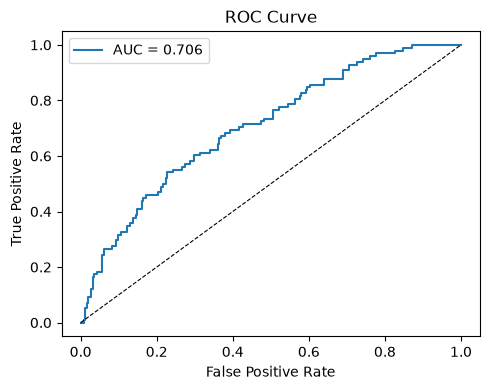

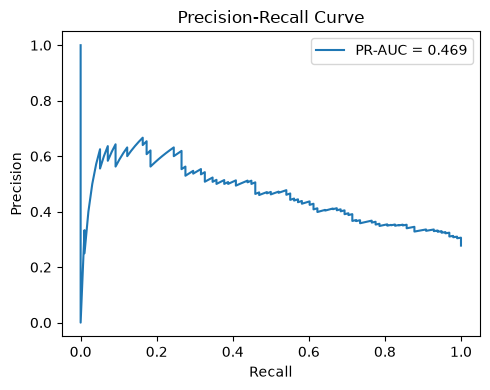

In [8]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC curve (displayed only — not saved)
fpr, tpr, _ = roc_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.show()

# Precision-Recall curve (displayed only — not saved)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_test, y_prob):.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Full-population operational risk scoring

In [9]:
# Score all 1,765 eligible customers (not just the test split)
full_prob = pd.Series(
    model.predict_proba(features[NUMERIC_FEATURES])[:, 1],
    index=features.index,
)

risk_table = build_customer_risk_table(features, full_prob)

print("Risk tiers:")
display(risk_table["Risk_Tier"].value_counts())
print()
display(risk_table.head())

Risk tiers:


Risk_Tier
Low Risk       706
Medium Risk    706
High Risk      353
Name: count, dtype: int64

,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,TotalItems,ActiveMonths,TenureDays,PurchaseSpanDays,Country,R,F,M,RFM_Score,RFM_Segment,Churn_90D,Churn_Probability,Risk_Tier,Retention_Priority
CustomerID,,,,,,,,,,,,,,,,,,,
12347.0,29,5,2790.86,558.172000,82,1590,5,267,238,Iceland,3,4,5,12,High Value,0,27.57,Low Risk,Relationship / loyalty attention
12348.0,148,3,1487.24,495.746667,22,2124,3,258,110,Finland,1,2,4,7,Medium Value,0,62.26,Medium Risk,Standard engagement
12352.0,162,5,1561.81,312.362000,26,254,2,196,34,Norway,1,4,4,9,Medium Value,0,70.48,High Risk,Targeted attention
12356.0,145,2,2753.08,1376.540000,53,1586,2,225,80,Portugal,1,1,5,7,Medium Value,0,71.54,High Risk,Targeted attention
12359.0,89,3,3495.73,1165.243333,135,965,3,231,142,Cyprus,2,2,5,9,Medium Value,0,50.09,Medium Risk,Standard engagement


## 9. Final integrity checks

In [10]:
# ── Data counts ──────────────────────────────────────────────────────────────
assert len(df_qualified) == 392_692, (
    f"Qualified rows mismatch: expected 392,692, got {len(df_qualified):,}"
)
assert len(eligible_ids) == 1_765, (
    f"Eligible customers mismatch: expected 1,765, got {len(eligible_ids):,}"
)

# ── Churn label distribution ──────────────────────────────────────────────────
assert future_inactive == 490, (
    f"Future inactive mismatch: expected 490, got {future_inactive}"
)
assert future_active == 1_275, (
    f"Future active mismatch: expected 1,275, got {future_active}"
)

# ── Train / test split ────────────────────────────────────────────────────────
assert len(X_train) == 1_412, (
    f"Train size mismatch: expected 1,412, got {len(X_train):,}"
)
assert len(X_test) == 353, (
    f"Test size mismatch: expected 353, got {len(X_test):,}"
)

# ── Model metrics ─────────────────────────────────────────────────────────────
assert abs(metrics["roc_auc"] - 0.7063) < 0.001, (
    f"ROC-AUC mismatch: expected 0.7063, got {metrics['roc_auc']:.4f}"
)
assert abs(metrics["pr_auc"] - 0.4686) < 0.001, (
    f"PR-AUC mismatch: expected 0.4686, got {metrics['pr_auc']:.4f}"
)

# ── Risk tier counts ──────────────────────────────────────────────────────────
tier_counts = risk_table["Risk_Tier"].value_counts()
assert tier_counts.get("Low Risk",  0) == 706, (
    f"Low Risk count mismatch: expected 706, got {tier_counts.get('Low Risk', 0)}"
)
assert tier_counts.get("Medium Risk", 0) == 706, (
    f"Medium Risk count mismatch: expected 706, got {tier_counts.get('Medium Risk', 0)}"
)
assert tier_counts.get("High Risk", 0) == 353, (
    f"High Risk count mismatch: expected 353, got {tier_counts.get('High Risk', 0)}"
)

# ── Temporal / leakage guards ─────────────────────────────────────────────────
# Observation window ends on 2011-08-31 (SNAPSHOT_DATE)
assert OBSERVATION_END.date() == SNAPSHOT_DATE.date()
# Future window starts strictly after snapshot
assert FUTURE_START.date() > OBSERVATION_END.date()
# All observation-period rows are on or before the snapshot date
assert (df_obs["InvoiceDate"].dt.date <= OBSERVATION_END.date()).all(), (
    "df_obs contains rows after OBSERVATION_END"
)
# All future-period rows are within the future window
assert (
    (df_future["InvoiceDate"].dt.date >= FUTURE_START.date())
    & (df_future["InvoiceDate"].dt.date <= FUTURE_END.date())
).all(), "df_future contains rows outside the future window"
# 2011-08-31 is included in df_obs
assert (df_obs["InvoiceDate"].dt.date == SNAPSHOT_DATE.date()).any(), (
    "Snapshot date 2011-08-31 not found in df_obs — intraday inclusion check failed"
)

# ── No future-window fields are predictors ────────────────────────────────────
for forbidden in [
    "FutureOrderCount", "FutureRevenue", "FutureRecency",
    "FutureFrequency", "FutureProducts", "future_purchase_count",
]:
    assert forbidden not in features.columns, (
        f"Leaked column '{forbidden}' found in feature table"
    )

# ── Schema guard ──────────────────────────────────────────────────────────────
assert list(df_raw.columns) == EXPECTED_COLUMNS, "Raw schema mismatch"

print("✓ All integrity checks PASSED")
print(f"  Qualified rows      : {len(df_qualified):,}")
print(f"  Eligible customers  : {len(eligible_ids):,}")
print(f"  Future inactive     : {future_inactive:,}")
print(f"  Future active       : {future_active:,}")
print(f"  Train / Test        : {len(X_train):,} / {len(X_test):,}")
print(f"  ROC-AUC             : {metrics['roc_auc']:.4f}")
print(f"  PR-AUC              : {metrics['pr_auc']:.4f}")
print(f"  Risk tiers          : Low={tier_counts.get('Low Risk',0)}, "
      f"Medium={tier_counts.get('Medium Risk',0)}, High={tier_counts.get('High Risk',0)}")

✓ All integrity checks PASSED
  Qualified rows      : 392,692
  Eligible customers  : 1,765
  Future inactive     : 490
  Future active       : 1,275
  Train / Test        : 1,412 / 353
  ROC-AUC             : 0.7063
  PR-AUC              : 0.4686
  Risk tiers          : Low=706, Medium=706, High=353


## Final verified project state

The project environment was validated with **141 automated tests passing**. The consolidated notebook uses the same repository modules, temporal definitions, predictor list, Logistic Regression pipeline, evaluation functions, and operational risk-tier logic as the published project.

No file is written during execution. All results are computed in memory and displayed above.

**GitHub:** https://github.com/TanmayChawhan/ecommerce-churn-analytics